In [713]:
import tensorflow as tf
import numpy as np
from pyDOE import lhs
import matplotlib.pyplot as plt

# import pydot
# import graphviz
# import math
# from matplotlib import cm
# from matplotlib.ticker import LinearLocator

import time
import random

In [714]:
tf.keras.backend.set_floatx('float64')

In [715]:
def rklv(constants, t_start, t_end, t_step_size) :
    
    [x0, y0, a, b, c, d] = constants
        
    def rk4(r, t, h):                    #edited; no need for input f
            """ Runge-Kutta 4 method """
            k1 = h*f(r, t)
            k2 = h*f(r+0.5*k1, t+0.5*h)
            k3 = h*f(r+0.5*k2, t+0.5*h)
            k4 = h*f(r+k3, t+h)
            return (k1 + 2*k2 + 2*k3 + k4)/6

    def f(r, t):
            x, y = r[0], r[1]
            fxd = a*x - b*x*y
            fyd = c*x*y - d*y
            return np.array([fxd, fyd], float)

    h = t_step_size                           
    tpoints = np.arange(t_start, t_end + h, h)        
    xpoints, ypoints  = [], []
    r = np.array([x0, y0], float)
    for t in tpoints:
            xpoints.append(r[0])         
            ypoints.append(r[1])         
            r += rk4(r, t, h)        
            
#     plt.plot(xpoints, ypoints)
#     plt.xlabel("x")
#     plt.ylabel("y")
#     plt.show()

    tarr = np.asarray(tpoints)
    xarr = np.asarray(xpoints)
    yarr = np.asarray(ypoints)

    points = np.vstack((tarr, xarr, yarr))

    return points

In [716]:
def define_collocation_points(t_bdry, N_points=100):

    colloc_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N_points)

    return colloc_points

In [717]:
M = 6
N = 10
P = 101


t0 = 0.0
tfinal = 10.0
t_step = 0.01

In [718]:
def build_model(num_layers = 4, num_units = 60, summary = False) :
    
    inp_br_init = tf.keras.layers.Input(shape = (2,), name = "Input_br_init")
    inp_br_param = tf.keras.layers.Input(shape = (4,), name = "Input_br_param")
    
    br = tf.keras.layers.Concatenate()([inp_br_init, inp_br_param])
    
    for i in range(num_layers) :
        
        br = tf.keras.layers.Dense(num_units, activation = 'tanh', name = "Hidden_br_" + str(i))(br)
        
    out_br_x = tf.keras.layers.Dense(1, activation = 'linear', name = "output_br_x")(br)
    out_br_y = tf.keras.layers.Dense(1, activation = 'linear', name = "output_br_y")(br)
    
    
    inp_tr = tr = tf.keras.layers.Input(shape = (1,), name = "Input_tr")
    
    for i in range(num_layers) :
        
        tr = tf.keras.layers.Dense(num_units, activation = 'tanh', name = "Hidden_tr_" + str(i))(tr)
        
    out_tr_x = tf.keras.layers.Dense(1, activation = 'linear', name = "output_tr_x")(tr)
    out_tr_y = tf.keras.layers.Dense(1, activation = 'linear', name = "output_tr_y")(tr)

    mult_x = tf.keras.layers.Multiply(name = "multiply_x")([out_br_x, out_tr_x])
    mult_y = tf.keras.layers.Multiply(name = "multiply_y")([out_br_y, out_tr_y])
    
    out_x = tf.keras.layers.Dense(1, name = "output_x")(mult_x)
    out_y = tf.keras.layers.Dense(1, name = "output_y")(mult_y)
    
    model = tf.keras.models.Model([inp_br_init, inp_br_param, inp_tr], [out_x, out_y])
    
    if summary :
        
        model.summary()
        
    return model

Model: "model_48"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Input_br_init (InputLayer)     [(None, 2)]          0           []                               
                                                                                                  
 Input_br_param (InputLayer)    [(None, 4)]          0           []                               
                                                                                                  
 concatenate_48 (Concatenate)   (None, 6)            0           ['Input_br_init[0][0]',          
                                                                  'Input_br_param[0][0]']         
                                                                                                  
 Input_tr (InputLayer)          [(None, 1)]          0           []                        

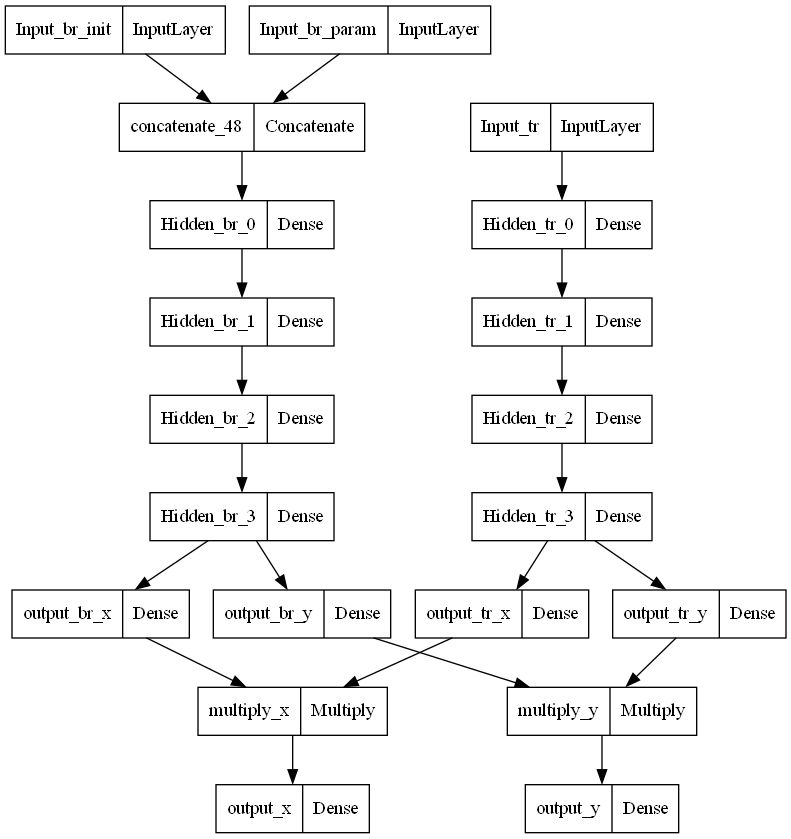

In [719]:
model = build_model(summary = True)
tf.keras.utils.plot_model(model, to_file = 'DeepOnet.png')

In [720]:
u_data = np.random.rand(N, M)

In [721]:
def clone_u_data (data) :
    
    new_data = np.zeros((N*P, M))
    
    for i in range(N) :
        
        data_row = data[i]
        
        cloned_data = np.tile(data_row, (P,1))
        
        new_data[i*P:(i + 1)*P, :] = cloned_data
        
    return new_data

In [722]:
def clone_t_data (data) :
    
    new_data = np.tile(data, (N,1))
    
    return new_data

In [723]:
print(u_data.shape)
u_data = clone_u_data(u_data)
print(u_data.shape)

u_train = u_data

(10, 6)
(1010, 6)


Text(0.5, 1.0, 'Collocation points being used')

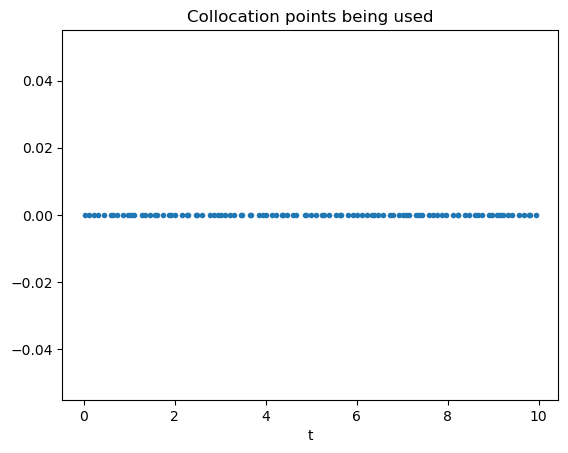

In [724]:
colloc = define_collocation_points([t0, tfinal], P)
plt.plot(colloc[:,0], 0 * colloc[:,0],'.')
plt.xlabel('t')
plt.title('Collocation points being used')

In [725]:
t_init = np.zeros((N*P, 1))

In [726]:
decimal_p = int((np.floor(np.log10(1/t_step))))
print(decimal_p)

2


In [727]:
t_data = colloc
print(t_data.shape)
t_data = clone_t_data(t_data)
print(t_data.shape)

t_data = np.around(t_data, decimal_p)
t_train = t_data

(101, 1)
(1010, 1)


In [728]:
true_data = np.zeros((N*P, 2))

for i in range(N*P) :
    
    u = u_train[i]
    t = t_train[i]
    
    sol_points = rklv(u, t0, tfinal, t_step)
    
    t_sol = sol_points[0]
    t_sol = np.around(t_sol, decimal_p)
    
    x_sol = sol_points[1]
    y_sol = sol_points[2]
    
    index = np.where(t_sol == t)
    
    true_data[i][0] = x_sol[index][0]
    true_data[i][1] = y_sol[index][0]
    
print(true_data.shape)

(1010, 2)


In [729]:
u_train[:, :2] = np.log(u_train[:, :2])
true_data = np.log(true_data)

In [730]:
# The main training function
@tf.function
def train_network(model, u_cond, u_param, t, x_true, y_true, x_init, y_init, V, a, b, c, d, alpha, beta, gamma, delta):

    with tf.GradientTape() as tape1:

        with tf.GradientTape(persistent=True) as tape2:
            
            tape2.watch(t)
            [x, y] = model([u_cond, u_param, t], training=True)

        xt = tape2.gradient(x, t)
        yt = tape2.gradient(y, t)
        
        xt = tf.reshape(xt, [N*P, 1])
        yt = tf.reshape(yt, [N*P, 1])
 
        Gloss = tf.reduce_mean(tf.square(x - x_true) + tf.square(y - y_true))
        
        eqn1 = xt - a + b*(tf.math.exp(y))
        eqn2 = yt - c*(tf.math.exp(x)) + d
        print("eqn1", eqn1)
        print("eqn2", eqn2)
        DEloss = tf.reduce_mean(tf.square(eqn1) + tf.square(eqn2))
                         
        [x_init_pred, y_init_pred] = model([u_cond, u_param, t_init], training=True)
        
        print("x_init", x_init)
        print("x_init", x_init)
        print("x_init_pred", x_init_pred)
        print("y_init_pred", y_init_pred)
        print("x", x)
        print("y", y)
        
        IVloss = tf.reduce_mean(tf.square(x_init_pred - x_init) + tf.square(y_init_pred - y_init))
    
        v = (c * (tf.math.exp(x))) - (d * x) + (b * tf.math.exp(y)) - (a * y)
    
        Vloss = tf.reduce_mean(tf.square(v - V))
        
        loss = beta*DEloss + gamma*IVloss + delta*Vloss

    grads = tape1.gradient(loss, model.trainable_variables)
    
    return DEloss, IVloss, Vloss, grads

In [731]:
def DeepONet_train(model, u, t, G_true, epochs, alpha_val, beta_val, gamma_val, delta_val):

    lr_model = 1e-3
    
    alpha = alpha_val
    beta = beta_val
    gamma = gamma_val
    delta = delta_val
    
    u_cond = u[:, :2]
    u_param = u[:, 2:]
    
    x_init = u[:, 0].reshape(-1, 1)
    y_init = u[:, 1].reshape(-1, 1)
    
    a = u[:, 2].reshape(-1, 1)
    b = u[:, 3].reshape(-1, 1)
    c = u[:, 4].reshape(-1, 1)
    d = u[:, 5].reshape(-1, 1)
    
    V = (c * (np.exp(x_init))) - (d * x_init) + (b * np.exp(y_init)) - (a * y_init)
      
    x_true = G_true[:, 0].reshape(-1, 1)
    y_true = G_true[:, 1].reshape(-1, 1)
    
    print(u_cond.shape, u_param.shape, x_init.shape, y_init.shape, 
          a.shape, b.shape, c.shape, d.shape, V.shape, x_true.shape, y_true.shape)

    epoch_loss = np.zeros(epochs)
    
    opt = tf.keras.optimizers.Adam(lr_model)

    for i in range(epochs):

        DEloss, IVloss, Vloss, grads = train_network(model, u_cond, u_param, t, x_true, y_true, x_init, y_init, V, 
                                                            a, b, c, d, alpha, beta, gamma, delta)

        opt.apply_gradients(zip(grads, model.trainable_variables))
      
        epoch_loss[i] += beta*DEloss + gamma*IVloss + delta*Vloss

    
        if (np.mod(i, 100)==0):
       
            print("DE loss, IV loss, Vloss in {}th epoch: {: 6.4f}, {: 6.4f}, {: 6.4f}.".format(
                i, DEloss, IVloss, Vloss))

    return epoch_loss, model

In [732]:
alpha = 0.0
beta = 12
gamma = 1.2
delta = 100

epochs = 100000

In [733]:
model = build_model()

loss, model = DeepONet_train(model, u_train, t_train, true_data, epochs, alpha, beta, gamma, delta)

(1010, 2) (1010, 4) (1010, 1) (1010, 1) (1010, 1) (1010, 1) (1010, 1) (1010, 1) (1010, 1) (1010, 1) (1010, 1)
eqn1 Tensor("add_1:0", shape=(1010, 1), dtype=float64)
eqn2 Tensor("add_2:0", shape=(1010, 1), dtype=float64)
x_init Tensor("x_init:0", shape=(1010, 1), dtype=float64)
x_init Tensor("x_init:0", shape=(1010, 1), dtype=float64)
x_init_pred Tensor("model_49/output_x/BiasAdd_1:0", shape=(1010, 1), dtype=float64)
y_init_pred Tensor("model_49/output_y/BiasAdd_1:0", shape=(1010, 1), dtype=float64)
x Tensor("model_49/output_x/BiasAdd:0", shape=(1010, 1), dtype=float64)
y Tensor("model_49/output_y/BiasAdd:0", shape=(1010, 1), dtype=float64)
DE loss, IV loss, Vloss in 0th epoch:  0.2464,  2.0089,  0.0549.
DE loss, IV loss, Vloss in 100th epoch:  0.1430,  0.0563,  0.0014.
DE loss, IV loss, Vloss in 200th epoch:  0.1309,  0.0777,  0.0011.
DE loss, IV loss, Vloss in 300th epoch:  0.1239,  0.1199,  0.0011.
DE loss, IV loss, Vloss in 400th epoch:  0.1225,  0.1223,  0.0012.
DE loss, IV loss, V

DE loss, IV loss, Vloss in 11100th epoch:  0.1175,  0.1219,  0.0013.
DE loss, IV loss, Vloss in 11200th epoch:  0.1175,  0.1227,  0.0013.
DE loss, IV loss, Vloss in 11300th epoch:  0.1174,  0.1225,  0.0013.
DE loss, IV loss, Vloss in 11400th epoch:  0.1176,  0.1226,  0.0013.
DE loss, IV loss, Vloss in 11500th epoch:  0.1159,  0.1210,  0.0015.
DE loss, IV loss, Vloss in 11600th epoch:  0.1170,  0.1234,  0.0014.
DE loss, IV loss, Vloss in 11700th epoch:  0.1173,  0.1221,  0.0013.
DE loss, IV loss, Vloss in 11800th epoch:  0.1183,  0.1186,  0.0013.
DE loss, IV loss, Vloss in 11900th epoch:  0.1176,  0.1231,  0.0013.
DE loss, IV loss, Vloss in 12000th epoch:  0.1192,  0.1323,  0.0011.
DE loss, IV loss, Vloss in 12100th epoch:  0.1165,  0.1238,  0.0014.
DE loss, IV loss, Vloss in 12200th epoch:  0.1169,  0.1229,  0.0014.
DE loss, IV loss, Vloss in 12300th epoch:  0.1191,  0.1290,  0.0011.
DE loss, IV loss, Vloss in 12400th epoch:  0.1175,  0.1232,  0.0013.
DE loss, IV loss, Vloss in 12500th

DE loss, IV loss, Vloss in 23000th epoch:  0.1049,  0.1400,  0.0017.
DE loss, IV loss, Vloss in 23100th epoch:  0.1050,  0.1405,  0.0017.
DE loss, IV loss, Vloss in 23200th epoch:  0.1050,  0.1408,  0.0017.
DE loss, IV loss, Vloss in 23300th epoch:  0.1059,  0.1418,  0.0016.
DE loss, IV loss, Vloss in 23400th epoch:  0.1051,  0.1410,  0.0017.
DE loss, IV loss, Vloss in 23500th epoch:  0.1052,  0.1412,  0.0017.
DE loss, IV loss, Vloss in 23600th epoch:  0.1049,  0.1413,  0.0017.
DE loss, IV loss, Vloss in 23700th epoch:  0.1036,  0.1406,  0.0019.
DE loss, IV loss, Vloss in 23800th epoch:  0.1048,  0.1422,  0.0017.
DE loss, IV loss, Vloss in 23900th epoch:  0.1042,  0.1415,  0.0018.
DE loss, IV loss, Vloss in 24000th epoch:  0.1047,  0.1418,  0.0017.
DE loss, IV loss, Vloss in 24100th epoch:  0.1048,  0.1422,  0.0017.
DE loss, IV loss, Vloss in 24200th epoch:  0.1042,  0.1423,  0.0017.
DE loss, IV loss, Vloss in 24300th epoch:  0.1049,  0.1420,  0.0017.
DE loss, IV loss, Vloss in 24400th

DE loss, IV loss, Vloss in 34900th epoch:  0.1038,  0.1412,  0.0018.
DE loss, IV loss, Vloss in 35000th epoch:  0.1038,  0.1413,  0.0017.
DE loss, IV loss, Vloss in 35100th epoch:  0.1038,  0.1415,  0.0017.
DE loss, IV loss, Vloss in 35200th epoch:  0.1038,  0.1417,  0.0017.
DE loss, IV loss, Vloss in 35300th epoch:  0.1037,  0.1417,  0.0018.
DE loss, IV loss, Vloss in 35400th epoch:  0.1037,  0.1419,  0.0017.
DE loss, IV loss, Vloss in 35500th epoch:  0.1038,  0.1400,  0.0018.
DE loss, IV loss, Vloss in 35600th epoch:  0.1036,  0.1419,  0.0018.
DE loss, IV loss, Vloss in 35700th epoch:  0.1036,  0.1419,  0.0018.
DE loss, IV loss, Vloss in 35800th epoch:  0.1039,  0.1420,  0.0017.
DE loss, IV loss, Vloss in 35900th epoch:  0.1036,  0.1422,  0.0017.
DE loss, IV loss, Vloss in 36000th epoch:  0.1034,  0.1420,  0.0018.
DE loss, IV loss, Vloss in 36100th epoch:  0.1036,  0.1424,  0.0017.
DE loss, IV loss, Vloss in 36200th epoch:  0.1037,  0.1429,  0.0017.
DE loss, IV loss, Vloss in 36300th

DE loss, IV loss, Vloss in 46800th epoch:  0.1032,  0.1459,  0.0017.
DE loss, IV loss, Vloss in 46900th epoch:  0.1026,  0.1460,  0.0018.
DE loss, IV loss, Vloss in 47000th epoch:  0.1028,  0.1464,  0.0018.
DE loss, IV loss, Vloss in 47100th epoch:  0.1039,  0.1455,  0.0017.
DE loss, IV loss, Vloss in 47200th epoch:  0.1037,  0.1478,  0.0017.
DE loss, IV loss, Vloss in 47300th epoch:  0.1026,  0.1464,  0.0018.
DE loss, IV loss, Vloss in 47400th epoch:  0.1028,  0.1460,  0.0018.
DE loss, IV loss, Vloss in 47500th epoch:  0.1029,  0.1460,  0.0018.
DE loss, IV loss, Vloss in 47600th epoch:  0.1043,  0.1474,  0.0016.
DE loss, IV loss, Vloss in 47700th epoch:  0.1029,  0.1468,  0.0017.
DE loss, IV loss, Vloss in 47800th epoch:  0.1023,  0.1453,  0.0018.
DE loss, IV loss, Vloss in 47900th epoch:  0.1028,  0.1465,  0.0018.
DE loss, IV loss, Vloss in 48000th epoch:  0.1027,  0.1459,  0.0018.
DE loss, IV loss, Vloss in 48100th epoch:  0.1025,  0.1463,  0.0018.
DE loss, IV loss, Vloss in 48200th

DE loss, IV loss, Vloss in 58700th epoch:  0.0964,  0.1742,  0.0018.
DE loss, IV loss, Vloss in 58800th epoch:  0.0963,  0.1767,  0.0018.
DE loss, IV loss, Vloss in 58900th epoch:  0.0962,  0.1775,  0.0017.
DE loss, IV loss, Vloss in 59000th epoch:  0.0960,  0.1785,  0.0017.
DE loss, IV loss, Vloss in 59100th epoch:  0.0959,  0.1797,  0.0017.
DE loss, IV loss, Vloss in 59200th epoch:  0.0966,  0.1741,  0.0018.
DE loss, IV loss, Vloss in 59300th epoch:  0.0963,  0.1760,  0.0018.
DE loss, IV loss, Vloss in 59400th epoch:  0.0962,  0.1766,  0.0018.
DE loss, IV loss, Vloss in 59500th epoch:  0.0962,  0.1770,  0.0018.
DE loss, IV loss, Vloss in 59600th epoch:  0.0962,  0.1772,  0.0018.
DE loss, IV loss, Vloss in 59700th epoch:  0.0961,  0.1775,  0.0018.
DE loss, IV loss, Vloss in 59800th epoch:  0.0961,  0.1778,  0.0018.
DE loss, IV loss, Vloss in 59900th epoch:  0.0960,  0.1783,  0.0017.
DE loss, IV loss, Vloss in 60000th epoch:  0.0961,  0.1790,  0.0017.
DE loss, IV loss, Vloss in 60100th

DE loss, IV loss, Vloss in 70600th epoch:  0.0936,  0.1938,  0.0017.
DE loss, IV loss, Vloss in 70700th epoch:  0.0933,  0.1947,  0.0017.
DE loss, IV loss, Vloss in 70800th epoch:  0.0925,  0.1947,  0.0018.
DE loss, IV loss, Vloss in 70900th epoch:  0.0932,  0.1950,  0.0017.
DE loss, IV loss, Vloss in 71000th epoch:  0.0933,  0.1951,  0.0017.
DE loss, IV loss, Vloss in 71100th epoch:  0.0930,  0.1938,  0.0018.
DE loss, IV loss, Vloss in 71200th epoch:  0.0925,  0.1970,  0.0018.
DE loss, IV loss, Vloss in 71300th epoch:  0.0933,  0.1959,  0.0017.
DE loss, IV loss, Vloss in 71400th epoch:  0.0938,  0.1958,  0.0016.
DE loss, IV loss, Vloss in 71500th epoch:  0.0919,  0.1971,  0.0019.
DE loss, IV loss, Vloss in 71600th epoch:  0.0935,  0.1960,  0.0017.
DE loss, IV loss, Vloss in 71700th epoch:  0.0933,  0.1959,  0.0017.
DE loss, IV loss, Vloss in 71800th epoch:  0.0929,  0.1964,  0.0017.
DE loss, IV loss, Vloss in 71900th epoch:  0.0931,  0.1960,  0.0017.
DE loss, IV loss, Vloss in 72000th

DE loss, IV loss, Vloss in 82500th epoch:  0.0940,  0.2017,  0.0016.
DE loss, IV loss, Vloss in 82600th epoch:  0.0919,  0.2025,  0.0018.
DE loss, IV loss, Vloss in 82700th epoch:  0.0923,  0.2019,  0.0017.
DE loss, IV loss, Vloss in 82800th epoch:  0.0910,  0.2037,  0.0019.
DE loss, IV loss, Vloss in 82900th epoch:  0.0922,  0.2020,  0.0017.
DE loss, IV loss, Vloss in 83000th epoch:  0.0927,  0.2013,  0.0017.
DE loss, IV loss, Vloss in 83100th epoch:  0.0925,  0.2020,  0.0017.
DE loss, IV loss, Vloss in 83200th epoch:  0.1134,  0.1254,  0.0012.
DE loss, IV loss, Vloss in 83300th epoch:  0.0978,  0.1724,  0.0015.
DE loss, IV loss, Vloss in 83400th epoch:  0.0914,  0.1937,  0.0018.
DE loss, IV loss, Vloss in 83500th epoch:  0.0915,  0.1926,  0.0018.
DE loss, IV loss, Vloss in 83600th epoch:  0.0913,  0.1935,  0.0018.
DE loss, IV loss, Vloss in 83700th epoch:  0.0915,  0.1946,  0.0018.
DE loss, IV loss, Vloss in 83800th epoch:  0.0913,  0.1949,  0.0017.
DE loss, IV loss, Vloss in 83900th

DE loss, IV loss, Vloss in 94400th epoch:  0.0887,  0.2086,  0.0018.
DE loss, IV loss, Vloss in 94500th epoch:  0.0892,  0.2081,  0.0018.
DE loss, IV loss, Vloss in 94600th epoch:  0.0890,  0.2080,  0.0018.
DE loss, IV loss, Vloss in 94700th epoch:  0.0890,  0.2085,  0.0018.
DE loss, IV loss, Vloss in 94800th epoch:  0.0896,  0.2074,  0.0017.
DE loss, IV loss, Vloss in 94900th epoch:  0.0893,  0.2082,  0.0017.
DE loss, IV loss, Vloss in 95000th epoch:  0.0897,  0.2073,  0.0017.
DE loss, IV loss, Vloss in 95100th epoch:  0.0891,  0.2086,  0.0018.
DE loss, IV loss, Vloss in 95200th epoch:  0.0903,  0.2077,  0.0016.
DE loss, IV loss, Vloss in 95300th epoch:  0.0886,  0.2090,  0.0018.
DE loss, IV loss, Vloss in 95400th epoch:  0.0889,  0.2077,  0.0018.
DE loss, IV loss, Vloss in 95500th epoch:  0.0895,  0.2084,  0.0017.
DE loss, IV loss, Vloss in 95600th epoch:  0.0900,  0.2080,  0.0017.
DE loss, IV loss, Vloss in 95700th epoch:  0.0895,  0.2069,  0.0017.
DE loss, IV loss, Vloss in 95800th

In [734]:
test_u = np.array([0.9, 0.9, 2/3, 1/3, 1, 1])
test_t = np.arange(0, tfinal + t_step, t_step)

sol = rklv(test_u, t0, tfinal, t_step)
x_sol = sol[1]
y_sol = sol[2]

test_u = np.tile(test_u, (len(test_t),1))
print(test_u.shape)

test_u_cond = np.log(test_u[:, :2])
test_u_param = test_u[:, 2:]

print(test_u_cond.shape)
print(test_u_param.shape)
print(test_t.shape)

(1001, 6)
(1001, 2)
(1001, 4)
(1001,)


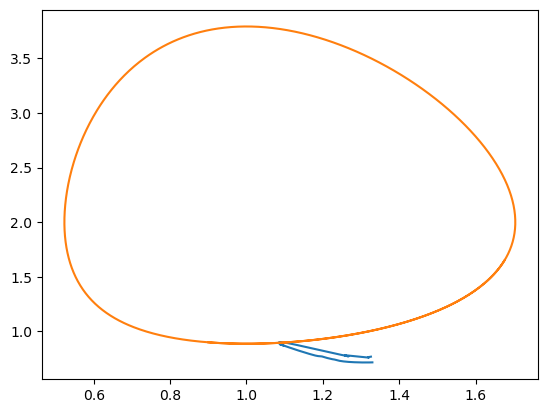

In [735]:
[test_x, test_y] = model([test_u_cond, test_u_param, test_t], training=True)

test_x = np.exp(test_x)
test_y = np.exp(test_y)

plt.figure()
plt.plot(test_x, test_y)
plt.plot(x_sol, y_sol)